# 02 - RFM Feature Engineering
**Goal:** Compute Recency, Frequency, and Monetary value for each customer — the foundation for all clustering in this project.

| Feature | Definition |
|---------|-----------|
| **Recency** | How many days since the customer's last purchase? |
| **Frequency** | How many unique orders has the customer placed? |
| **Monetary** | What is the customer's total spend? |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
df = pd.read_csv('../data/processed/retail_cleaned.csv', parse_dates=['InvoiceDate'])

print(f"Shape: {df.shape}")
df.head()

Shape: (776941, 12)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,DayOfWeek,Hour,Year
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,Tuesday,7,2009
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,Tuesday,7,2009
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,Tuesday,7,2009
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,Tuesday,7,2009
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,Tuesday,7,2009


## 1. Define Reference Date
We use the day after the last transaction as our "snapshot date" for computing Recency.

In [4]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date}")

Snapshot date: 2011-12-10 12:50:00


## 2. Compute RFM per Customer

In [5]:
rfm = df.groupby('Customer ID').agg(
    Recency = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary = ('TotalPrice', 'sum')
).reset_index()

print(f"RFM shape: {rfm.shape}")
rfm.head(10)

RFM shape: (5862, 4)


,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,4921.53
2,12348,75,5,1658.40
3,12349,19,3,3678.69
4,12350,310,1,294.40
5,12351,375,1,300.93
6,12352,36,9,1729.54
7,12353,204,2,406.76
8,12354,232,1,1079.40
9,12355,214,2,947.61


## 3. RFM Descriptive Statistics

In [6]:
rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2)

,Recency,Frequency,Monetary
count,5862.00,5862.00,5862.00
mean,200.87,6.26,2916.82
std,209.10,12.81,14337.15
min,1.00,1.00,2.95
25%,26.00,1.00,338.72
50%,95.50,3.00,855.22
75%,379.00,7.00,2237.03
max,739.00,379.00,580987.04


## 4. RFM Observations
- **Recency:** Ranges from 1 to 739 days. 50% of customers haven't purchased in over 95 days
- **Frequency:** Median of 3 orders, but max of 379 — extreme outliers likely wholesale accounts
- **Monetary:** Median spend £855, max £580,987 — heavy right skew confirms B2B buyers in the mix
- All three features are **heavily right-skewed** — log transformation will be needed before clustering

## 5. RFM Distributions

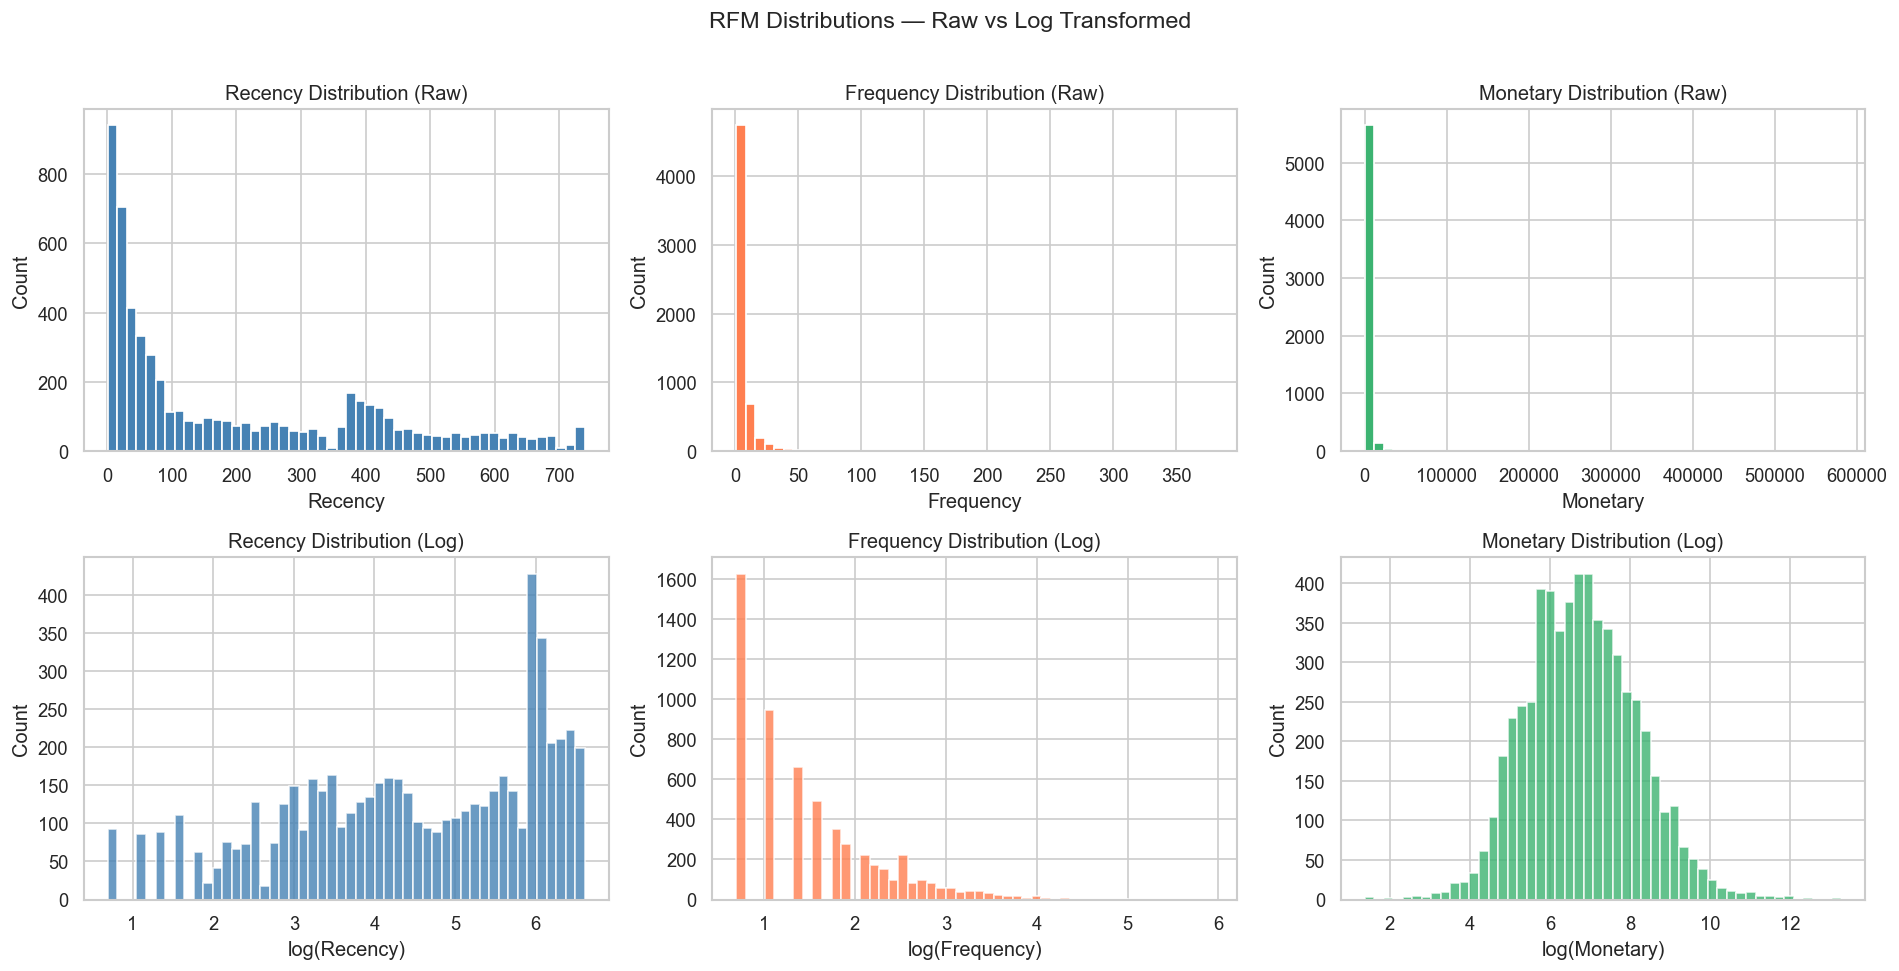

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Raw distributions
for ax, col, color in zip(axes[0], ['Recency', 'Frequency', 'Monetary'], 
                           ['steelblue', 'coral', 'mediumseagreen']):
    ax.hist(rfm[col], bins=50, color=color, edgecolor='white')
    ax.set_title(f'{col} Distribution (Raw)')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

# Log distributions
for ax, col, color in zip(axes[1], ['Recency', 'Frequency', 'Monetary'], 
                           ['steelblue', 'coral', 'mediumseagreen']):
    ax.hist(np.log1p(rfm[col]), bins=50, color=color, edgecolor='white', alpha=0.8)
    ax.set_title(f'{col} Distribution (Log)')
    ax.set_xlabel(f'log({col})')
    ax.set_ylabel('Count')

plt.suptitle('RFM Distributions — Raw vs Log Transformed', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/rfm_distributions.png')
plt.show()

## 6. Log Transform & Standardise
Clustering algorithms like K-Means are distance-based — features must be on the same scale.
We log-transform to reduce skew, then standardise to zero mean and unit variance.

In [8]:
from sklearn.preprocessing import StandardScaler

rfm_log = rfm.copy()
rfm_log['Recency']   = np.log1p(rfm['Recency'])
rfm_log['Frequency'] = np.log1p(rfm['Frequency'])
rfm_log['Monetary']  = np.log1p(rfm['Monetary'])

scaler = StandardScaler()
rfm_scaled = rfm_log.copy()
rfm_scaled[['Recency', 'Frequency', 'Monetary']] = scaler.fit_transform(
    rfm_log[['Recency', 'Frequency', 'Monetary']]
)

print("Log transform & scaling done ✓")
rfm_scaled[['Recency', 'Frequency', 'Monetary']].describe().round(3)

Log transform & scaling done ✓


,Recency,Frequency,Monetary
count,5862.000,5862.000,5862.000
mean,0.000,-0.000,-0.000
std,1.000,1.000,1.000
min,-2.410,-1.056,-3.927
25%,-0.741,-1.056,-0.706
50%,0.076,-0.199,-0.038
75%,0.955,0.659,0.657
max,1.382,5.436,4.676


## 7. RFM Correlation Check

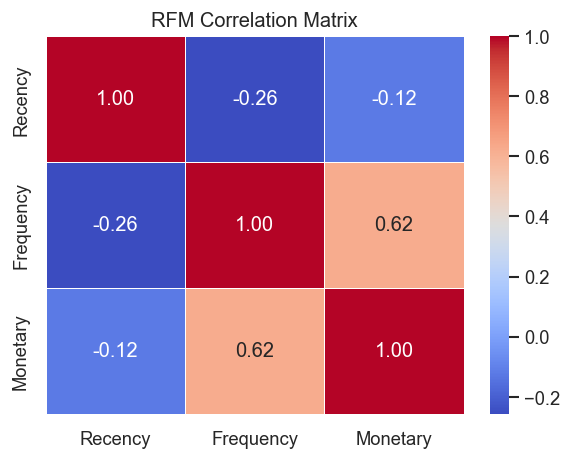

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(rfm[['Recency', 'Frequency', 'Monetary']].corr(), 
            annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, ax=ax)
ax.set_title('RFM Correlation Matrix')
plt.tight_layout()
plt.savefig('../reports/figures/rfm_correlation.png')
plt.show()

## 8. Save RFM Features

In [10]:
# Save raw RFM (for reference and profiling later)
rfm.to_csv('../data/processed/rfm.csv', index=False)

# Save scaled RFM (for clustering)
rfm_scaled.to_csv('../data/processed/rfm_scaled.csv', index=False)

print("Saved rfm.csv ✓")
print("Saved rfm_scaled.csv ✓")
print(f"\nFinal RFM shape: {rfm.shape}")

Saved rfm.csv ✓
Saved rfm_scaled.csv ✓

Final RFM shape: (5862, 4)


## 9. Observations
- **Frequency & Monetary are moderately correlated (0.62)** — higher order frequency naturally leads to higher total spend
- **Recency is largely independent of Monetary (-0.12)** — a high-spend customer can still be inactive, reinforcing the need for all three dimensions
- No multicollinearity issues — all three RFM features carry distinct information and are safe to use together in clustering

## 9. RFM Scatter Plots
Visualising how customers are distributed across RFM dimensions.

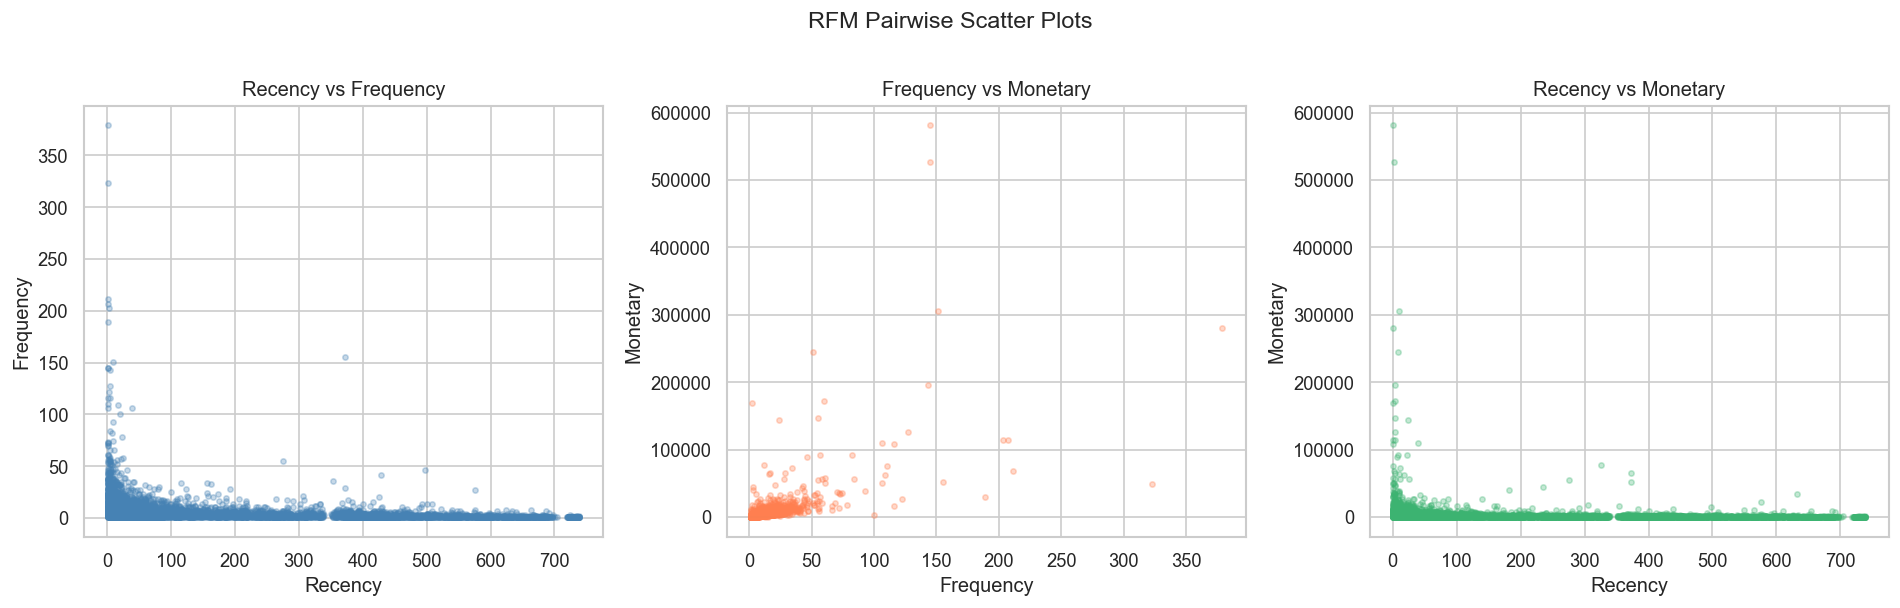

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [('Recency', 'Frequency'), ('Frequency', 'Monetary'), ('Recency', 'Monetary')]
colors = ['steelblue', 'coral', 'mediumseagreen']

for ax, (x, y), color in zip(axes, pairs, colors):
    ax.scatter(rfm[x], rfm[y], alpha=0.3, s=10, color=color)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}')

plt.suptitle('RFM Pairwise Scatter Plots', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/rfm_scatterplots.png')
plt.show()

### Insight
- The majority of customers are clustered in the low Recency, low Frequency, low Monetary zone
- A small number of outliers have extremely high Frequency (up to 379) and Monetary (up to £580K)
- These outliers are likely wholesale accounts and will form their own natural cluster
- Raw RFM is not suitable for clustering directly — log scaling is essential

## 10. RFM Quantile Scoring (Business Baseline)
Assigning scores 1–4 to each RFM dimension based on quartiles.
Note: For Recency, lower is better (recent purchase = high score), so scoring is reversed.

In [12]:
rfm_scored = rfm.copy()

rfm_scored['R_Score'] = pd.qcut(rfm['Recency'],  q=4, labels=[4, 3, 2, 1])
rfm_scored['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm_scored['M_Score'] = pd.qcut(rfm['Monetary'],  q=4, labels=[1, 2, 3, 4])

rfm_scored['RFM_Score'] = (rfm_scored['R_Score'].astype(int) + 
                            rfm_scored['F_Score'].astype(int) + 
                            rfm_scored['M_Score'].astype(int))

print(rfm_scored[['Customer ID', 'Recency', 'Frequency', 'Monetary', 
                   'R_Score', 'F_Score', 'M_Score', 'RFM_Score']].head(10))
print(f"\nRFM Score range: {rfm_scored['RFM_Score'].min()} — {rfm_scored['RFM_Score'].max()}")

   Customer ID  Recency  Frequency  Monetary R_Score F_Score M_Score  \
0        12346      326         12  77556.46       2       4       4   
1        12347        2          8   4921.53       4       4       4   
2        12348       75          5   1658.40       3       3       3   
3        12349       19          3   3678.69       4       2       4   
4        12350      310          1    294.40       2       1       1   
5        12351      375          1    300.93       2       1       1   
6        12352       36          9   1729.54       3       4       3   
7        12353      204          2    406.76       2       2       2   
8        12354      232          1   1079.40       2       1       3   
9        12355      214          2    947.61       2       2       3   

   RFM_Score  
0         10  
1         12  
2          9  
3         10  
4          4  
5          4  
6         10  
7          6  
8          6  
9          7  

RFM Score range: 3 — 12


## 11. Top & Bottom Customer Profiles

In [13]:
top_customers = rfm_scored.nlargest(10, 'RFM_Score')[
    ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'RFM_Score']
].reset_index(drop=True)

bottom_customers = rfm_scored.nsmallest(10, 'RFM_Score')[
    ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'RFM_Score']
].reset_index(drop=True)

print("Top 10 Customers:")
print(top_customers.to_string(index=False))
print("\nBottom 10 Customers:")
print(bottom_customers.to_string(index=False))

Top 10 Customers:
 Customer ID  Recency  Frequency  Monetary  RFM_Score
       12347        2          8   4921.53         12
       12362        3         10   4737.23         12
       12380       22          8   7210.65         12
       12388       16          8   3901.11         12
       12395       19         15   4241.17         12
       12415       24         24 144033.37         12
       12417        3         20   5998.41         12
       12423        1         10   2301.39         12
       12428       26          8   6405.26         12
       12429        9          8   5842.41         12

Bottom 10 Customers:
 Customer ID  Recency  Frequency  Monetary  RFM_Score
       12387      415          1    143.94          3
       12392      591          1    234.75          3
       12400      414          1    205.25          3
       12404      682          1     63.24          3
       12416      657          1    202.56          3
       12460      456          1    296.65

## 12. Customer Segment Distribution (RFM Score Buckets)
Mapping RFM scores to business-friendly segment labels.

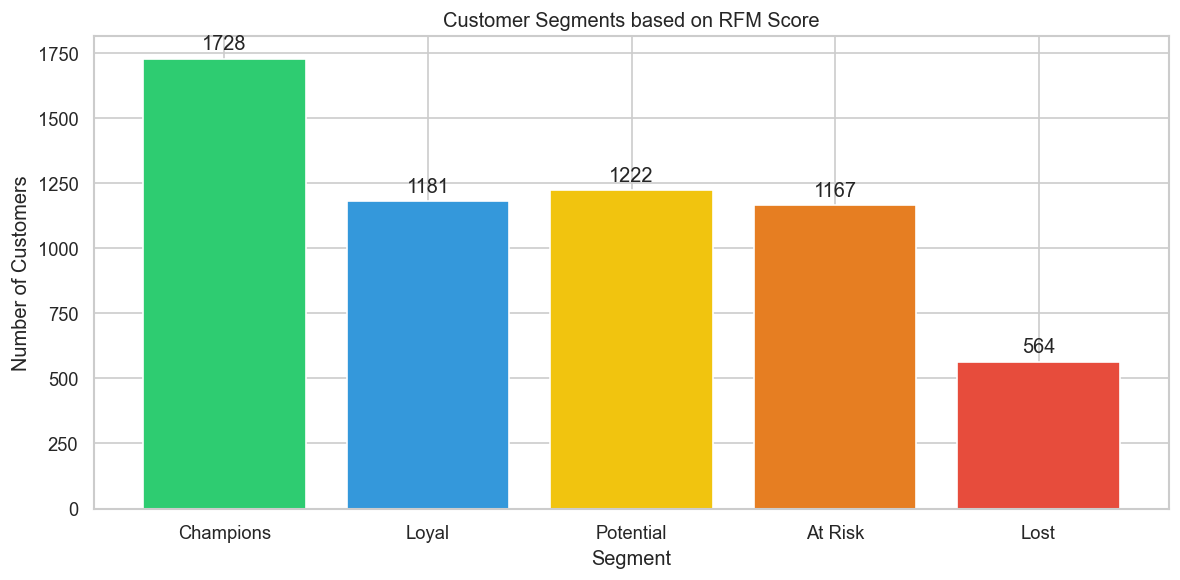

Segment
Champions    1728
Loyal        1181
Potential    1222
At Risk      1167
Lost          564
Name: count, dtype: int64


In [14]:
def rfm_segment(score):
    if score >= 10:
        return 'Champions'
    elif score >= 8:
        return 'Loyal'
    elif score >= 6:
        return 'Potential'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost'

rfm_scored['Segment'] = rfm_scored['RFM_Score'].apply(rfm_segment)

segment_counts = rfm_scored['Segment'].value_counts()
order = ['Champions', 'Loyal', 'Potential', 'At Risk', 'Lost']
segment_counts = segment_counts.reindex(order)

colors = ['#2ecc71', '#3498db', '#f1c40f', '#e67e22', '#e74c3c']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(segment_counts.index, segment_counts.values, color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%d', padding=3)
ax.set_title('Customer Segments based on RFM Score')
ax.set_xlabel('Segment')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('../reports/figures/rfm_segments.png')
plt.show()

print(segment_counts)

### Insight
- **Champions (1,728 customers)** are recent, frequent, and high-spending — the core of the business
- **Lost (564 customers)** are long-inactive single-order customers — costly to reactivate
- **At Risk (1,167)** were once active but are drifting — prime targets for win-back campaigns
- Top customers (score 12/12) purchased within the last month with 8–24 orders
- Bottom customers (score 3/12) last purchased 400–730 days ago with a single order
- This quantile-based segmentation is a **business baseline** — Notebook 3 will use ML clustering to find more nuanced, data-driven segments

## 13. Save RFM Scored Data

In [15]:
rfm_scored.to_csv('../data/processed/rfm_scored.csv', index=False)
print("Saved rfm_scored.csv ✓")
print(f"Shape: {rfm_scored.shape}")
print(f"\nSegment distribution:\n{rfm_scored['Segment'].value_counts()}")

Saved rfm_scored.csv ✓
Shape: (5862, 9)

Segment distribution:
Segment
Champions    1728
Potential    1222
Loyal        1181
At Risk      1167
Lost          564
Name: count, dtype: int64
